# Feature Engineering - Support Ticket Classification

This notebook extracts features from preprocessed text:
- TF-IDF vectorization
- Bag of Words (BoW)
- Additional text features
- Feature comparison and selection
- Prepare data for modeling

In [1]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from src.feature_extraction import (
    FeatureExtractor,
    extract_text_features,
    encode_labels
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Processed Data

In [2]:
# Load preprocessed data
df = pd.read_csv('../data/processed/tickets_processed.csv')
print(f"✓ Loaded {len(df):,} processed tickets")
print(f"  Columns: {list(df.columns)}")

# Load metadata
metadata = pd.read_csv('../data/processed/preprocessing_metadata.csv')
text_col = metadata['text_column'].values[0]
category_col = metadata['category_column'].values[0]
cleaned_col = metadata['cleaned_column'].values[0]

print(f"\n✓ Text column: {text_col}")
print(f"✓ Category column: {category_col}")
print(f"✓ Cleaned column: {cleaned_col}")

✓ Loaded 8,469 processed tickets
  Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'Ticket Description_cleaned', 'cleaned_length', 'cleaned_word_count', 'priority']

✓ Text column: Ticket Description
✓ Category column: Ticket Type
✓ Cleaned column: Ticket Description_cleaned


In [3]:
# Display sample
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Description_cleaned,cleaned_length,cleaned_word_count,priority
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,im issue productpurchased please assist billin...,195,26,Low
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,im issue productpurchased please assist need c...,179,24,Low
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,im facing problem productpurchased productpurc...,170,20,Low
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,im issue productpurchased please assist proble...,183,25,Low
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,im issue productpurchased please assist note s...,220,29,Low


## 2. TF-IDF Feature Extraction

In [4]:
# Extract TF-IDF features
print("Extracting TF-IDF features...\n")

tfidf_extractor = FeatureExtractor(
    method='tfidf',
    max_features=5000,
    ngram_range=(1, 2)  # Unigrams and bigrams
)

X_tfidf = tfidf_extractor.fit_transform(df[cleaned_col])

print(f"\n✓ TF-IDF features extracted")
print(f"  Feature matrix shape: {X_tfidf.shape}")
print(f"  Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.2%}")

Extracting TF-IDF features...

✓ Extracted 5000 features using TFIDF
✓ Feature matrix shape: (8469, 5000)

✓ TF-IDF features extracted
  Feature matrix shape: (8469, 5000)
  Sparsity: 99.24%


In [5]:
# Display top TF-IDF features
feature_names = tfidf_extractor.get_feature_names()

print("\nTop 30 TF-IDF Features:")
print("="*60)

# Calculate mean TF-IDF score for each feature
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_indices = mean_tfidf.argsort()[-30:][::-1]

for i, idx in enumerate(top_indices, 1):
    print(f"{i:2d}. {feature_names[idx]:20s} (score: {mean_tfidf[idx]:.4f})")


Top 30 TF-IDF Features:
 1. issue                (score: 0.0588)
 2. im                   (score: 0.0527)
 3. please               (score: 0.0504)
 4. assist               (score: 0.0402)
 5. please assist        (score: 0.0401)
 6. im issue             (score: 0.0397)
 7. productpurchased please (score: 0.0394)
 8. issue productpurchased (score: 0.0394)
 9. ive                  (score: 0.0379)
10. product              (score: 0.0262)
11. problem              (score: 0.0255)
12. update               (score: 0.0213)
13. data                 (score: 0.0193)
14. account              (score: 0.0189)
15. software             (score: 0.0185)
16. device               (score: 0.0183)
17. step                 (score: 0.0176)
18. work                 (score: 0.0161)
19. time                 (score: 0.0160)
20. persists             (score: 0.0159)
21. issue persists       (score: 0.0159)
22. help                 (score: 0.0153)
23. noticed              (score: 0.0153)
24. ive noticed          (s

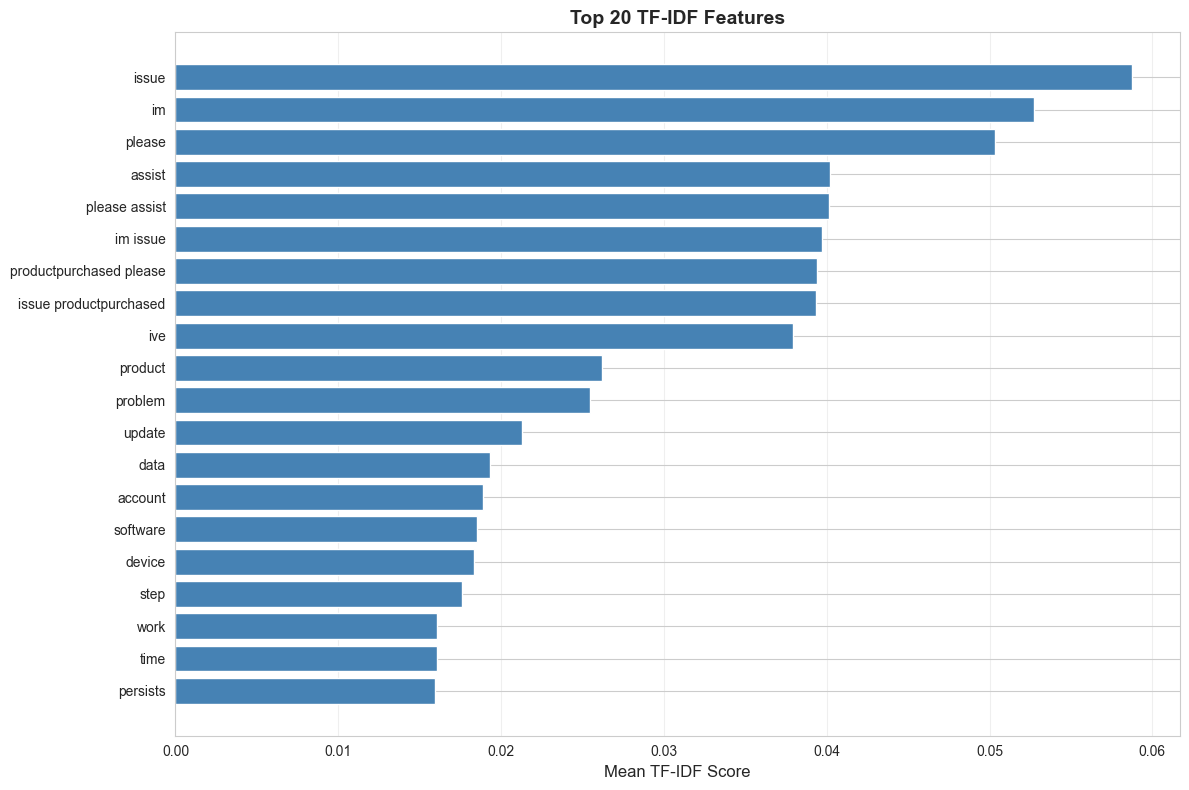

✓ Plot saved to: outputs/top_tfidf_features.png


In [6]:
# Visualize top TF-IDF features
top_n = 20
top_indices = mean_tfidf.argsort()[-top_n:][::-1]
top_features = [feature_names[i] for i in top_indices]
top_scores = [mean_tfidf[i] for i in top_indices]

plt.figure(figsize=(12, 8))
plt.barh(range(top_n), top_scores, color='steelblue')
plt.yticks(range(top_n), top_features)
plt.xlabel('Mean TF-IDF Score', fontsize=12)
plt.title(f'Top {top_n} TF-IDF Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/top_tfidf_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: outputs/top_tfidf_features.png")

## 3. Bag of Words (BoW) Feature Extraction

In [7]:
# Extract BoW features
print("Extracting Bag of Words features...\n")

bow_extractor = FeatureExtractor(
    method='bow',
    max_features=5000,
    ngram_range=(1, 2)
)

X_bow = bow_extractor.fit_transform(df[cleaned_col])

print(f"\n✓ BoW features extracted")
print(f"  Feature matrix shape: {X_bow.shape}")
print(f"  Sparsity: {(1.0 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])):.2%}")

Extracting Bag of Words features...

✓ Extracted 5000 features using BOW
✓ Feature matrix shape: (8469, 5000)

✓ BoW features extracted
  Feature matrix shape: (8469, 5000)
  Sparsity: 99.24%


## 4. Additional Text Features

In [8]:
# Extract additional text features
print("Extracting additional text features...\n")

df_features = extract_text_features(df, cleaned_col)

# BUGFIX: Add the priority column from the original dataframe
# The extract_text_features function doesn't copy this column,
# but we need it for encoding later
df_features['priority'] = df['Ticket Priority']

# Display feature statistics
additional_features = ['char_count', 'word_count', 'avg_word_length', 
                       'uppercase_ratio', 'exclamation_count', 'question_count']

print("\nAdditional Feature Statistics:")
print("="*60)
print(df_features[additional_features].describe())

Extracting additional text features...

✓ Extracted 6 additional text features

Additional Feature Statistics:
        char_count   word_count  avg_word_length  uppercase_ratio  \
count  8469.000000  8469.000000      8469.000000           8469.0   
mean    186.047821    24.569607         7.287860              0.0   
std      32.345084     4.296825         0.504174              0.0   
min      97.000000    12.000000         5.527778              0.0   
25%     169.000000    22.000000         6.958333              0.0   
50%     189.000000    25.000000         7.250000              0.0   
75%     208.000000    28.000000         7.551724              0.0   
max     315.000000    46.000000        11.235294              0.0   

       exclamation_count  question_count  
count             8469.0          8469.0  
mean                 0.0             0.0  
std                  0.0             0.0  
min                  0.0             0.0  
25%                  0.0             0.0  
50%      

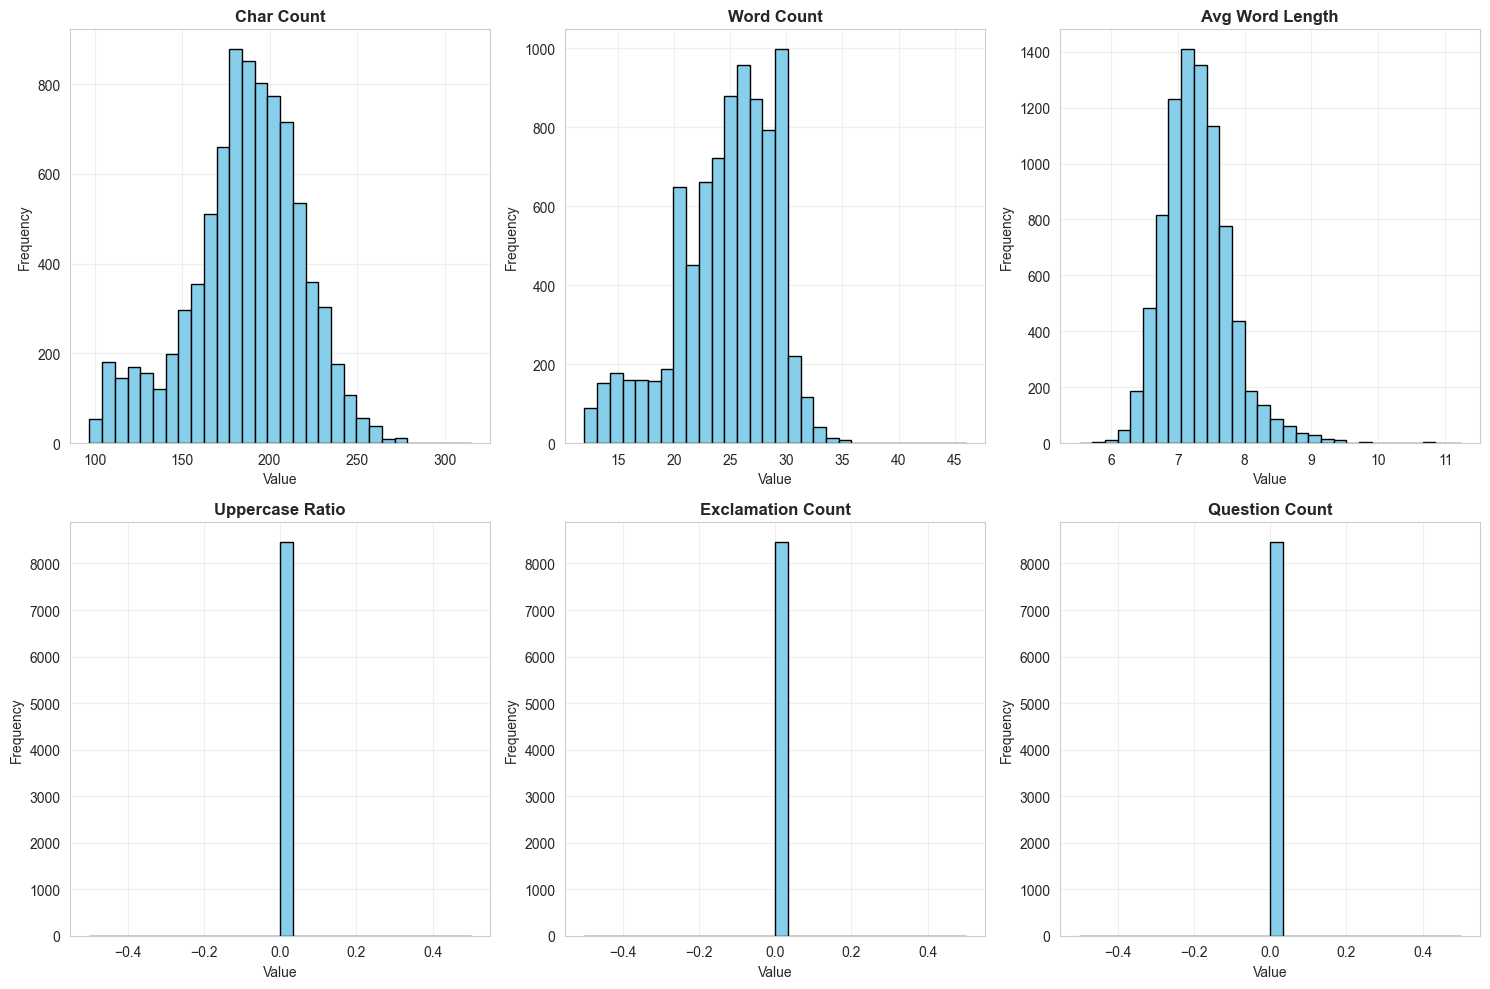

✓ Plot saved to: outputs/additional_features.png


In [9]:
# Visualize additional features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(additional_features):
    axes[idx].hist(df_features[feature], bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/additional_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: outputs/additional_features.png")

## 5. Encode Labels

In [10]:
# Encode category labels
print("Encoding category labels...\n")
y_category, category_encoder = encode_labels(df_features[category_col])

# Encode priority labels
print("\nEncoding priority labels...\n")
y_priority, priority_encoder = encode_labels(df_features['priority'])

print("\n✓ Labels encoded successfully")

Encoding category labels...

✓ Encoded 5 classes: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']

Encoding priority labels...

✓ Encoded 4 classes: ['Critical', 'High', 'Low', 'Medium']

✓ Labels encoded successfully


## 6. Train-Test Split

In [11]:
# Split data for category classification
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_tfidf, y_category, test_size=0.2, random_state=42, stratify=y_category
)

print("Category Classification Split:")
print("="*60)
print(f"Training set: {X_train_cat.shape[0]:,} samples")
print(f"Test set: {X_test_cat.shape[0]:,} samples")
print(f"Feature dimensions: {X_train_cat.shape[1]:,}")

# Split data for priority prediction
X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X_tfidf, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

print("\nPriority Prediction Split:")
print("="*60)
print(f"Training set: {X_train_pri.shape[0]:,} samples")
print(f"Test set: {X_test_pri.shape[0]:,} samples")
print(f"Feature dimensions: {X_train_pri.shape[1]:,}")

Category Classification Split:
Training set: 6,775 samples
Test set: 1,694 samples
Feature dimensions: 5,000

Priority Prediction Split:
Training set: 6,775 samples
Test set: 1,694 samples
Feature dimensions: 5,000


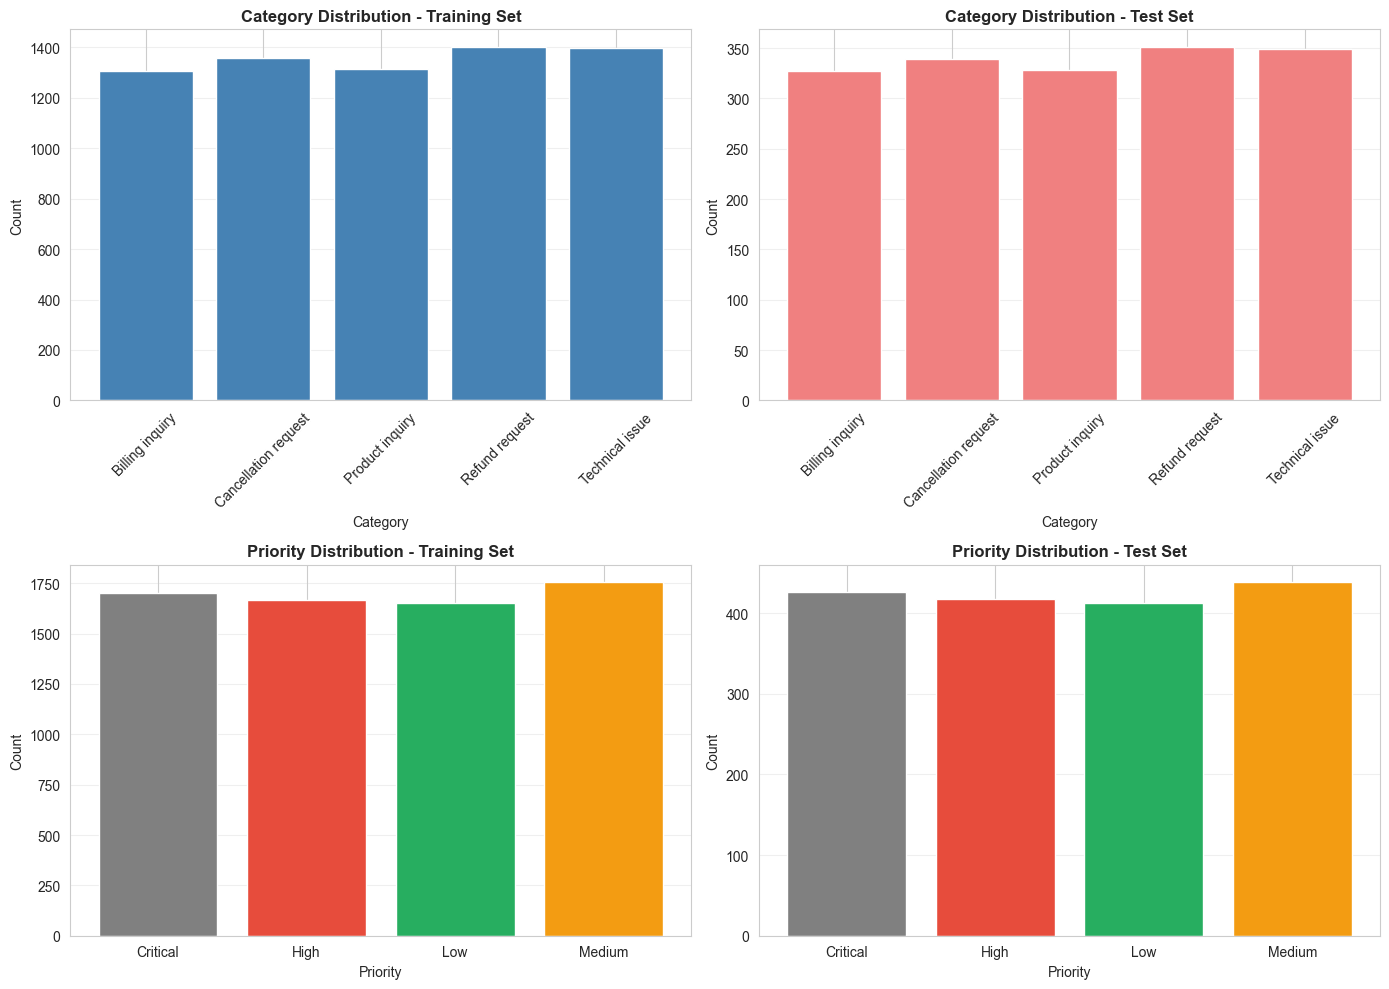

✓ Plot saved to: outputs/train_test_distribution.png


In [12]:
# Visualize class distribution in train/test sets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Category - Training
unique, counts = np.unique(y_train_cat, return_counts=True)
labels_cat = [category_encoder.classes_[i] for i in unique]
axes[0, 0].bar(labels_cat, counts, color='steelblue')
axes[0, 0].set_title('Category Distribution - Training Set', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Category - Test
unique, counts = np.unique(y_test_cat, return_counts=True)
labels_cat = [category_encoder.classes_[i] for i in unique]
axes[0, 1].bar(labels_cat, counts, color='lightcoral')
axes[0, 1].set_title('Category Distribution - Test Set', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Priority - Training
unique, counts = np.unique(y_train_pri, return_counts=True)
labels_pri = [priority_encoder.classes_[i] for i in unique]
colors_pri = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}
bar_colors = [colors_pri.get(label, 'gray') for label in labels_pri]
axes[1, 0].bar(labels_pri, counts, color=bar_colors)
axes[1, 0].set_title('Priority Distribution - Training Set', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Priority')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(axis='y', alpha=0.3)

# Priority - Test
unique, counts = np.unique(y_test_pri, return_counts=True)
labels_pri = [priority_encoder.classes_[i] for i in unique]
bar_colors = [colors_pri.get(label, 'gray') for label in labels_pri]
axes[1, 1].bar(labels_pri, counts, color=bar_colors)
axes[1, 1].set_title('Priority Distribution - Test Set', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Priority')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/train_test_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: outputs/train_test_distribution.png")

## 7. Save Features and Encoders

In [13]:
# Save feature extractors
joblib.dump(tfidf_extractor, '../models/tfidf_extractor.pkl')
joblib.dump(bow_extractor, '../models/bow_extractor.pkl')
print("✓ Feature extractors saved")

# Save label encoders
joblib.dump(category_encoder, '../models/category_encoder.pkl')
joblib.dump(priority_encoder, '../models/priority_encoder.pkl')
print("✓ Label encoders saved")

# Save train/test splits
np.savez_compressed(
    '../data/processed/category_classification_data.npz',
    X_train=X_train_cat,
    X_test=X_test_cat,
    y_train=y_train_cat,
    y_test=y_test_cat
)
print("✓ Category classification data saved")

np.savez_compressed(
    '../data/processed/priority_prediction_data.npz',
    X_train=X_train_pri,
    X_test=X_test_pri,
    y_train=y_train_pri,
    y_test=y_test_pri
)
print("✓ Priority prediction data saved")

✓ Feature extractors saved
✓ Label encoders saved
✓ Category classification data saved
✓ Priority prediction data saved


## 8. Feature Engineering Summary

In [14]:
print("FEATURE ENGINEERING COMPLETE!")
print("="*80)
print("\nWhat we accomplished:")
print(f"✓ Extracted TF-IDF features: {X_tfidf.shape[1]:,} features")
print(f"✓ Extracted BoW features: {X_bow.shape[1]:,} features")
print(f"✓ Extracted {len(additional_features)} additional text features")
print(f"✓ Encoded category labels: {len(category_encoder.classes_)} classes")
print(f"✓ Encoded priority labels: {len(priority_encoder.classes_)} classes")
print(f"✓ Created train/test splits (80/20)")
print(f"✓ Saved all features and encoders")
print("\nNext steps:")
print("1. Train classification models → 04_model_training.ipynb")
print("2. Evaluate model performance → 05_evaluation.ipynb")

FEATURE ENGINEERING COMPLETE!

What we accomplished:
✓ Extracted TF-IDF features: 5,000 features
✓ Extracted BoW features: 5,000 features
✓ Extracted 6 additional text features
✓ Encoded category labels: 5 classes
✓ Encoded priority labels: 4 classes
✓ Created train/test splits (80/20)
✓ Saved all features and encoders

Next steps:
1. Train classification models → 04_model_training.ipynb
2. Evaluate model performance → 05_evaluation.ipynb
